# Convergence of the mean-width estimator

Loads the JSON produced by `scripts/run_convergence.py` and plots:
1. Mean width ± 1 std vs N
2. Std vs N on log-log (expected slope: −½)
3. Coefficient of variation (%) vs N

In [15]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [16]:
MODE = "cnn" # "mlp" or "cnn"
RESULTS_PATH = f"../results/convergence_{MODE}"

In [21]:
mode="" if MODE == "mlp" else "_cnn" # fix
with open(os.path.join(RESULTS_PATH, f"convergence{mode}_sample3_bits4.json")) as f:
    data = json.load(f)

N_grid  = data["n_directions_grid"]
raw     = data["results"]

# JSON keys are strings; cast back to int for sorting
means = np.array([raw[str(N)]["mean"] for N in N_grid])
stds  = np.array([raw[str(N)]["std"]  for N in N_grid])
cvs   = stds / means * 100   # coefficient of variation (%)

print(f"Sample idx   : {data['sample_idx']}")
print(f"Bits         : {data['bits']}")
print(f"Replications : {data['n_replications']}")
print(f"N grid       : {N_grid}")
print()
print(f"{'N':>6}  {'mean':>10}  {'std':>8}  {'CV %':>7}")
print("-" * 38)
for N, m, s, cv in zip(N_grid, means, stds, cvs):
    print(f"{N:>6}  {m:>10.4f}  {s:>8.4f}  {cv:>7.2f}")

Sample idx   : 3
Bits         : 4
Replications : 20
N grid       : [10, 25, 50, 100, 150, 200]

     N        mean       std     CV %
--------------------------------------
    10      0.9834    0.0229     2.33
    25      0.9784    0.0088     0.90
    50      0.9778    0.0106     1.09
   100      0.9804    0.0042     0.42
   150      0.9780    0.0060     0.61
   200      0.9773    0.0043     0.44


Plot saved to ../results/convergence_cnn


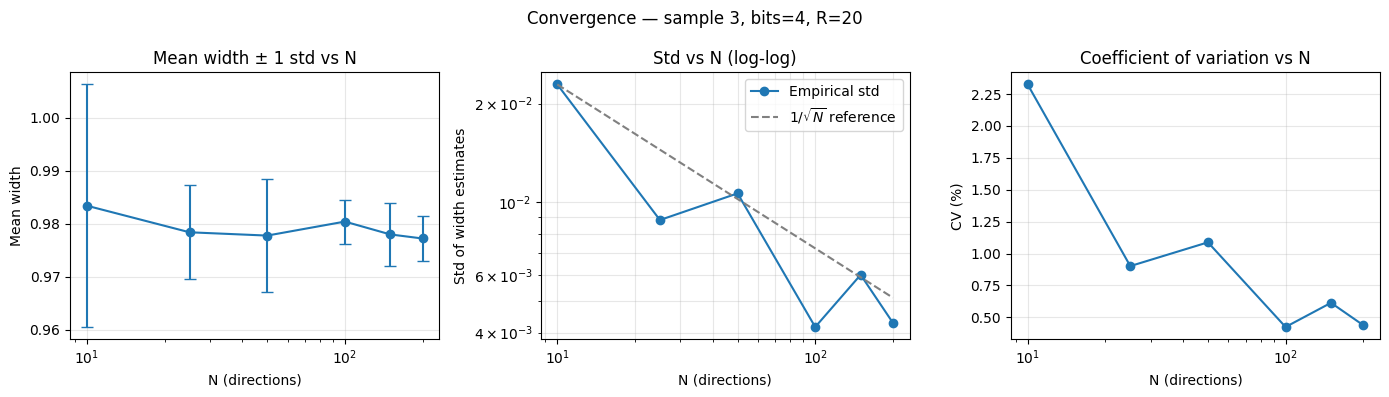

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
N_arr = np.array(N_grid, dtype=float)

# ── Panel 1: mean width ± 1 std vs N ────────────────────────────────────────
ax = axes[0]
ax.errorbar(N_grid, means, yerr=stds, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("N (directions)")
ax.set_ylabel("Mean width")
ax.set_title("Mean width ± 1 std vs N")
ax.grid(True, alpha=0.3)

# ── Panel 2: std vs N log-log with 1/√N reference ───────────────────────────
ax = axes[1]
ax.loglog(N_grid, stds, "o-", label="Empirical std")
scale = stds[0] * np.sqrt(N_arr[0])
ax.loglog(N_grid, scale / np.sqrt(N_arr), "--", color="gray", label=r"$1/\sqrt{N}$ reference")
ax.set_xlabel("N (directions)")
ax.set_ylabel("Std of width estimates")
ax.set_title("Std vs N (log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# ── Panel 3: coefficient of variation vs N ───────────────────────────────────
ax = axes[2]
ax.plot(N_grid, cvs, "o-")
ax.set_xscale("log")
ax.set_xlabel("N (directions)")
ax.set_ylabel("CV (%)")
ax.set_title("Coefficient of variation vs N")
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Convergence — sample {data['sample_idx']}, bits={data['bits']}, R={data['n_replications']}",
    fontsize=12,
)
plt.tight_layout()

out_path = RESULTS_PATH.replace(".json", "_plot.pdf")
plt.savefig(out_path, bbox_inches="tight")
print(f"Plot saved to {out_path}")
plt.show()

In [23]:
def plot_convergence(data_id, results_dir):

    mode="" if "mlp" in results_dir else "_cnn" # fix
    RESULTS_PATH = f"{results_dir}/convergence{mode}_sample{data_id}_bits4.json"

    with open(RESULTS_PATH) as f:
        data = json.load(f)

    N_grid  = data["n_directions_grid"]
    raw     = data["results"]

    # JSON keys are strings; cast back to int for sorting
    means = np.array([raw[str(N)]["mean"] for N in N_grid])
    stds  = np.array([raw[str(N)]["std"]  for N in N_grid])
    # cvs   = stds / means * 100   # coefficient of variation (%)


    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    N_arr = np.array(N_grid, dtype=float)

    ax.errorbar(N_grid, means, yerr=stds, fmt="o-", capsize=4)
    # ax.set_xscale("log")
    ax.set_xlabel("Number of directions")
    ax.set_ylabel("Polytope volume (eestimate)")
    ax.set_title(f"Sample {data_id}")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    out_path = RESULTS_PATH.replace(".json", "_plot.pdf")
    plt.savefig(out_path, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()

20
Plot saved to ../results/convergence_cnn/convergence_cnn_sample0_bits4_plot.pdf


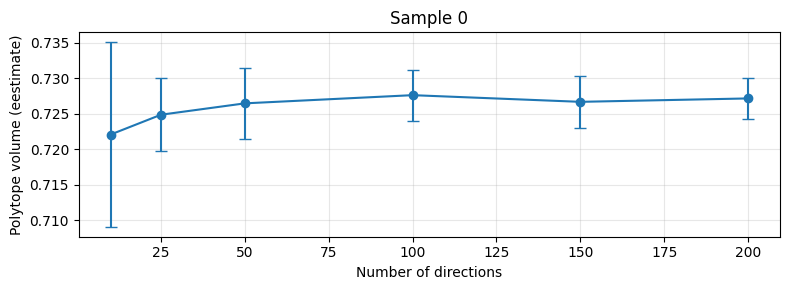

Plot saved to ../results/convergence_cnn/convergence_cnn_sample1_bits4_plot.pdf


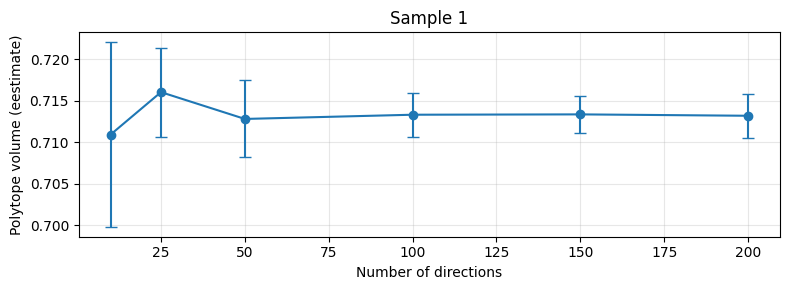

Plot saved to ../results/convergence_cnn/convergence_cnn_sample2_bits4_plot.pdf


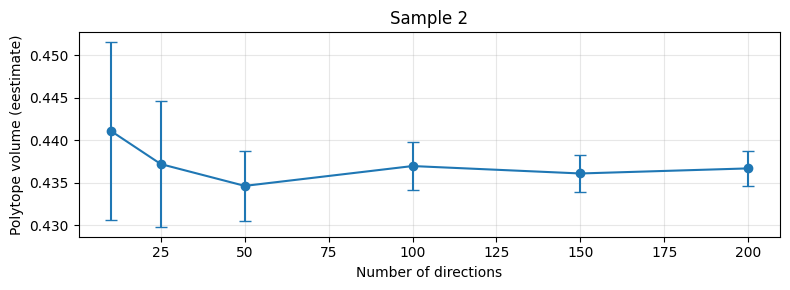

Plot saved to ../results/convergence_cnn/convergence_cnn_sample3_bits4_plot.pdf


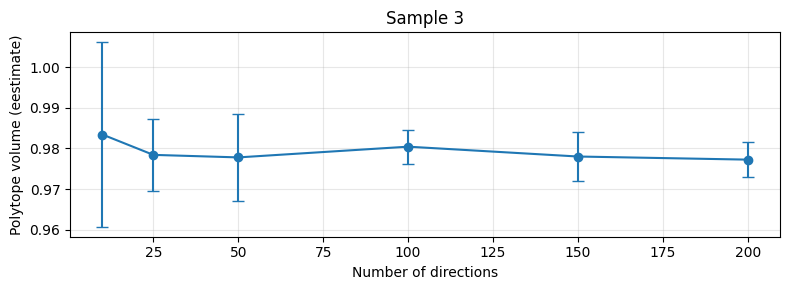

Plot saved to ../results/convergence_cnn/convergence_cnn_sample4_bits4_plot.pdf


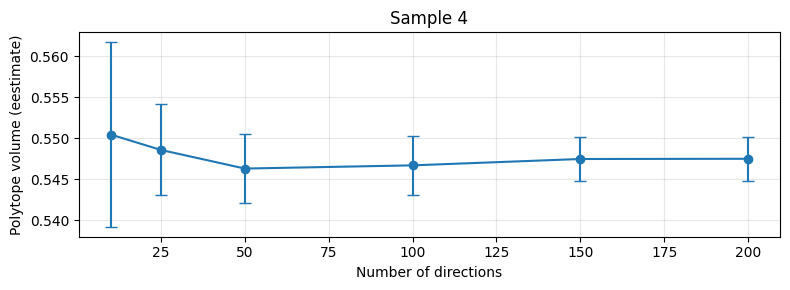

Plot saved to ../results/convergence_cnn/convergence_cnn_sample5_bits4_plot.pdf


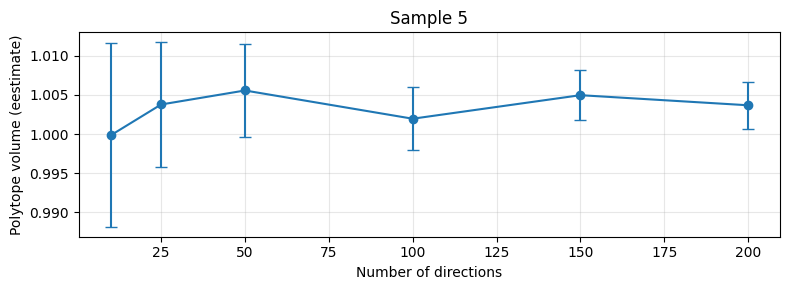

Plot saved to ../results/convergence_cnn/convergence_cnn_sample6_bits4_plot.pdf


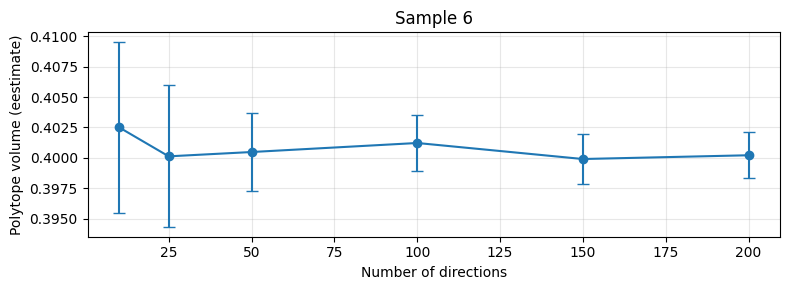

Plot saved to ../results/convergence_cnn/convergence_cnn_sample7_bits4_plot.pdf


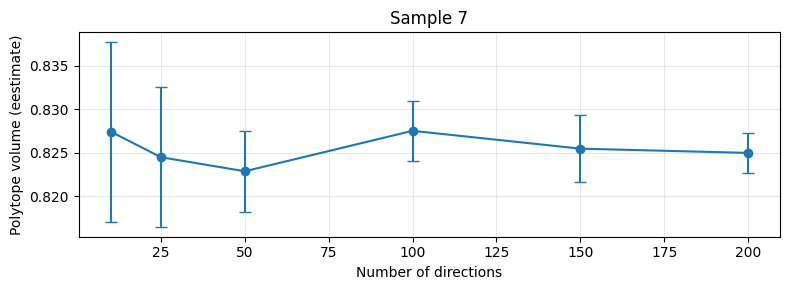

Plot saved to ../results/convergence_cnn/convergence_cnn_sample8_bits4_plot.pdf


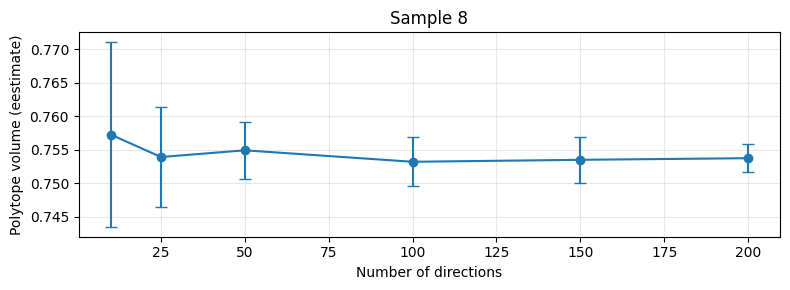

Plot saved to ../results/convergence_cnn/convergence_cnn_sample9_bits4_plot.pdf


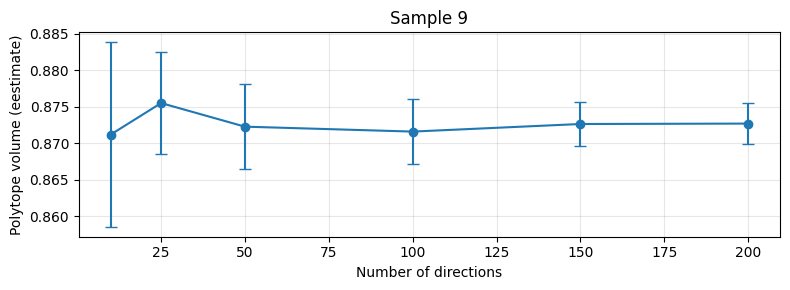

FileNotFoundError: [Errno 2] No such file or directory: '../results/convergence_cnn/convergence_cnn_sample10_bits4.json'

In [ ]:
nb_samples = len(os.listdir(RESULTS_PATH)) // 2  # Assuming each sample has a corresponding JSON and PDF file
print(nb_samples)

for data_id in range(nb_samples):

    plot_convergence(data_id, results_dir=RESULTS_PATH)